In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [97]:
df=pd.read_csv('archive/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [98]:
df.shape

(8807, 12)

As we can see, the dataset has 8807 rows with 12 columns


I want to see how many types of movies are there and there value count. So i choose bar plot and value_count() to get types and plot them out.

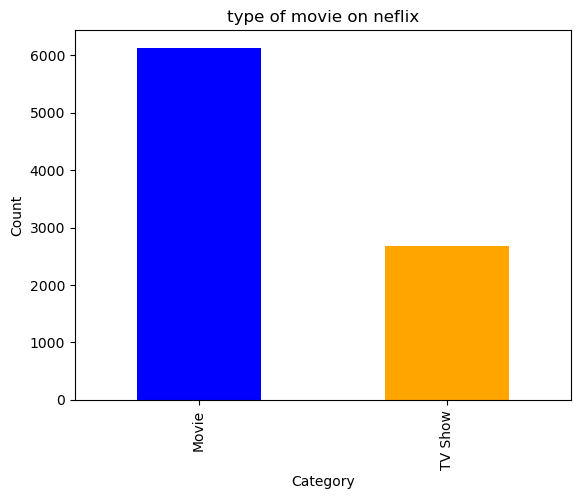

In [99]:
count=df['type'].value_counts()
count.plot(kind='bar',color=['blue','orange'])
plt.title('type of movie on neflix')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

we want to know about the title of each movie, try the print title. Beside that we can also see which movie's name has the longest length.

In [100]:
movie_names_str = df['title'].to_list()
print(movie_names_str)


['Dick Johnson Is Dead', 'Blood & Water', 'Ganglands', 'Jailbirds New Orleans', 'Kota Factory', 'Midnight Mass', 'My Little Pony: A New Generation', 'Sankofa', 'The Great British Baking Show', 'The Starling', 'Vendetta: Truth, Lies and The Mafia', 'Bangkok Breaking', 'Je Suis Karl', 'Confessions of an Invisible Girl', 'Crime Stories: India Detectives', 'Dear White People', "Europe's Most Dangerous Man: Otto Skorzeny in Spain", 'Falsa identidad', 'Intrusion', 'Jaguar', 'Monsters Inside: The 24 Faces of Billy Milligan', 'Resurrection: Ertugrul', 'Avvai Shanmughi', 'Go! Go! Cory Carson: Chrissy Takes the Wheel', 'Jeans', 'Love on the Spectrum', 'Minsara Kanavu', 'Grown Ups', 'Dark Skies', 'Paranoia', 'Ankahi Kahaniya', 'Chicago Party Aunt', 'Sex Education', 'Squid Game', 'Tayo and Little Wizards', 'The Father Who Moves Mountains', 'The Stronghold', 'Angry Birds', 'Birth of the Dragon', 'Chhota Bheem', 'He-Man and the Masters of the Universe', 'Jaws', 'Jaws 2', 'Jaws 3', 'Jaws: The Revenge

In [101]:
# Find the length of each movie title
df['title_length'] = df['title'].str.len()

# Find the movie with the maximum title length
longest_title_movie = df.loc[df['title_length'].idxmax()]

# Print the longest title and its length
print(f"Longest title: {longest_title_movie['title']}")
print(f"Length: {longest_title_movie['title_length']}")

Longest title: Jim & Andy: The Great Beyond - Featuring a Very Special, Contractually Obligated Mention of Tony Clifton
Length: 104


About the director, we can see how many time did a person become a director of a movie, and also who had the highest number of standing as the director.

In [102]:
count=df['director'].value_counts()


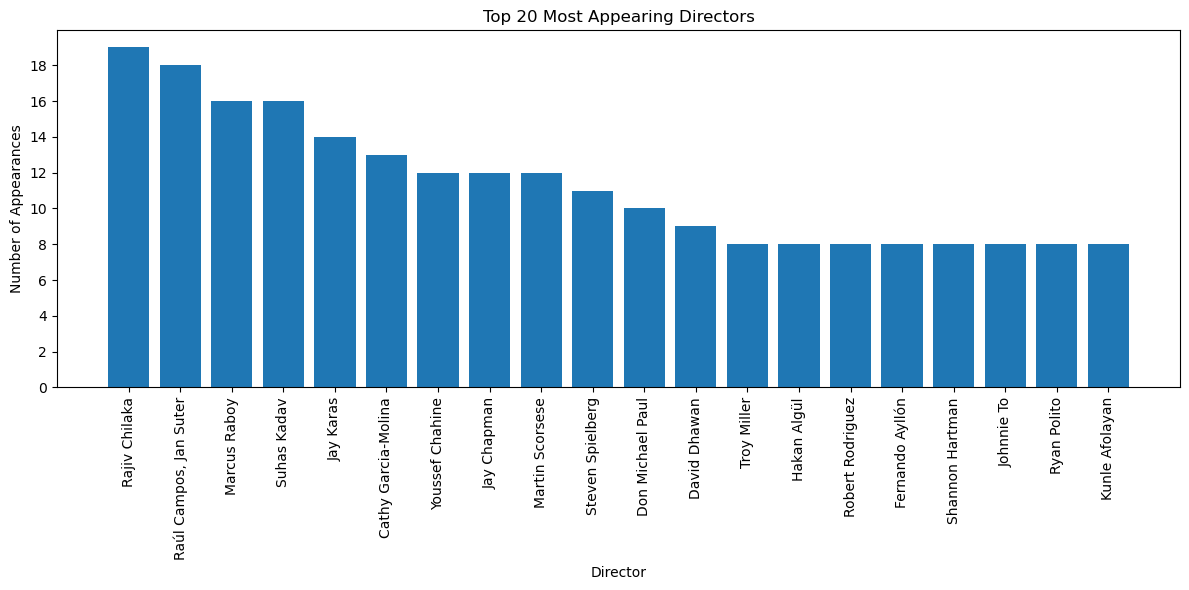

In [103]:
from matplotlib.ticker import MaxNLocator
top_20_directors = count.sort_values(ascending=False).head(20)

# Create a bar chart
plt.figure(figsize=(12, 6))  # Adjust figure size as needed
plt.bar(top_20_directors.index, top_20_directors.values)

# Customize the chart
plt.title('Top 20 Most Appearing Directors')
plt.xlabel('Director')
plt.ylabel('Number of Appearances')
plt.xticks(rotation=90)  
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()  

In [104]:
from collections import defaultdict

director_genres = defaultdict(lambda: defaultdict(int))

for index, row in df.iterrows():
    director = row['director']
    genres = row['listed_in'].split(', ')  # Assuming genres are separated by ', '
    for genre in genres:
        director_genres[director][genre] += 1

# Find most frequent genre for each director
director_most_frequent_genre = {}
for director, genre_counts in director_genres.items():
    most_frequent_genre = max(genre_counts, key=genre_counts.get)
    director_most_frequent_genre[director] = most_frequent_genre
#remove Nan value in dict
director_most_frequent_genre = {
    director: genre
    for director, genre in director_most_frequent_genre.items()
    if director is not np.nan and genre is not np.nan and isinstance(director, str)
}
print(director_most_frequent_genre)

{'Kirsten Johnson': 'Documentaries', 'Julien Leclercq': 'Dramas', 'Mike Flanagan': 'Horror Movies', 'Robert Cullen, José Luis Ucha': 'Children & Family Movies', 'Haile Gerima': 'Dramas', 'Andy Devonshire': 'British TV Shows', 'Theodore Melfi': 'Comedies', 'Kongkiat Komesiri': 'Crime TV Shows', 'Christian Schwochow': 'Dramas', 'Bruno Garotti': 'Comedies', 'Pedro de Echave García, Pablo Azorín Williams': 'Documentaries', 'Adam Salky': 'Thrillers', 'Olivier Megaton': 'Crime TV Shows', 'K.S. Ravikumar': 'Comedies', 'Alex Woo, Stanley Moore': 'Children & Family Movies', 'S. Shankar': 'Comedies', 'Rajiv Menon': 'International Movies', 'Dennis Dugan': 'Comedies', 'Scott Stewart': 'Horror Movies', 'Robert Luketic': 'Comedies', 'Ashwiny Iyer Tiwari, Abhishek Chaubey, Saket Chaudhary': 'Dramas', 'Daniel Sandu': 'Dramas', 'Cédric Jimenez': 'Action & Adventure', 'George Nolfi': 'Action & Adventure', 'Steven Spielberg': 'Dramas', 'Jeannot Szwarc': 'Dramas', 'Joe Alves': 'Action & Adventure', 'Josep

Besides that we can also calculate the top famous genre with the number of directors 

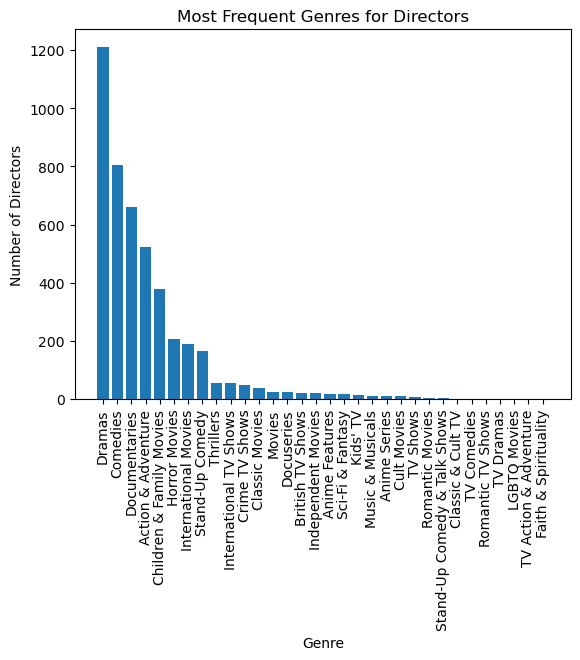

In [105]:
director_genre_counts = defaultdict(int)
for director, most_frequent_genre in director_most_frequent_genre.items():
    director_genre_counts[most_frequent_genre] += 1

# Filter out genres with zero counts
director_genre_counts = {genre: count for genre, count in director_genre_counts.items() if count > 0}

# Sort genres by frequency (rest of the code remains the same)
sorted_genres = sorted(director_genre_counts.items(), key=lambda item: item[1], reverse=True)

# Plot the data
genres, counts = zip(*sorted_genres)
plt.bar(genres, counts)
plt.xticks(rotation=90)
plt.title('Most Frequent Genres for Directors')
plt.xlabel('Genre')
plt.ylabel('Number of Directors')
plt.show()

I want to see the world map to visualize the distribution of movies across the word

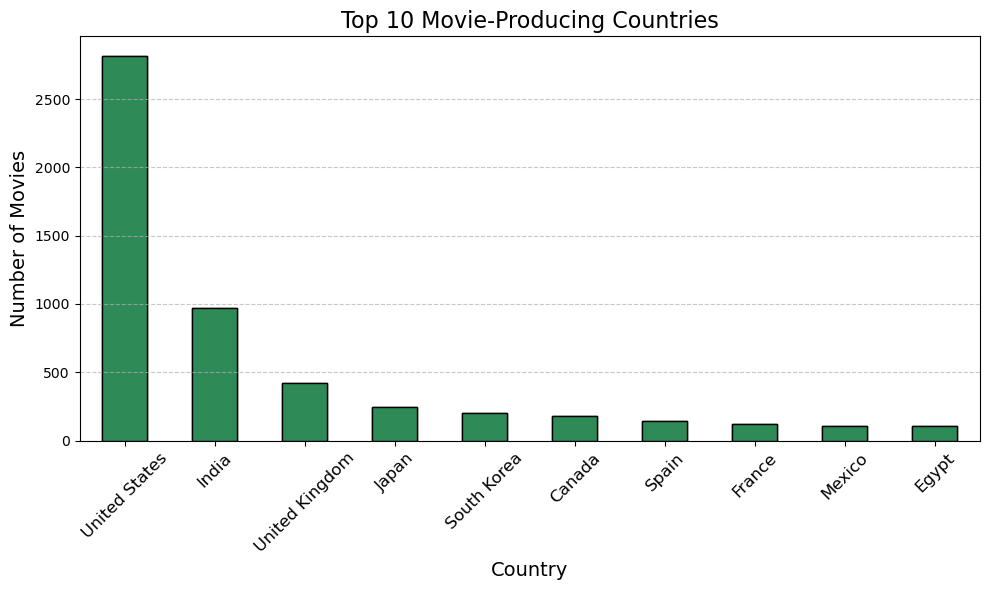

In [109]:
country_counts = df['country'].value_counts()
# Plot the distribution
plt.figure(figsize=(10, 6))
country_counts.plot(kind='bar', color='skyblue', edgecolor='black')
top_n = 10
top_countries = country_counts.head(top_n)
top_countries.plot(kind='bar', color='seagreen', edgecolor='black')
plt.title(f'Top {top_n} Movie-Producing Countries', fontsize=16)
# Add labels and title

plt.xlabel('Country', fontsize=14)
plt.ylabel('Number of Movies', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

release year analysis

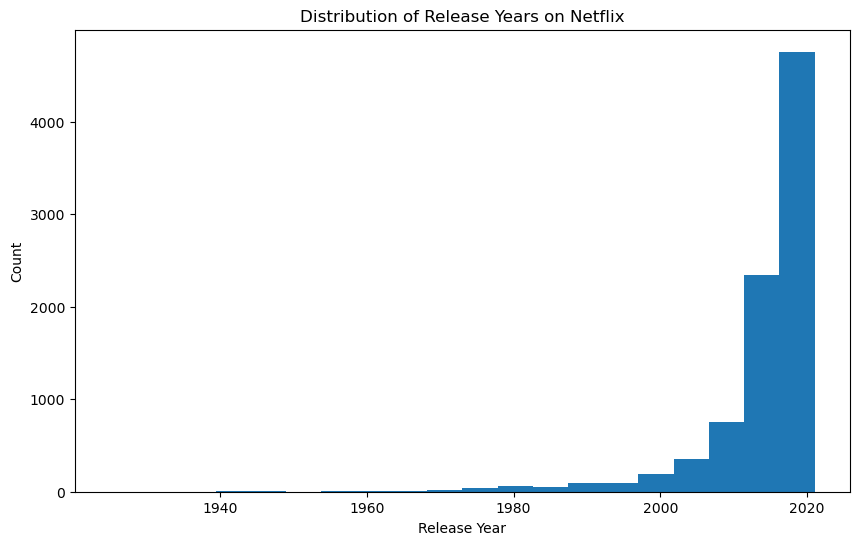

In [110]:
plt.figure(figsize=(10, 6))
plt.hist(df['release_year'], bins=20)  # Adjust bins as needed
plt.title('Distribution of Release Years on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

As we can see that most of the movies released after 2020 with over 5000 movies

/tmp/ipykernel_9121/977526410.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  content_added_by_month = df.groupby(pd.Grouper(key='date_added', freq='M'))['title'].count()


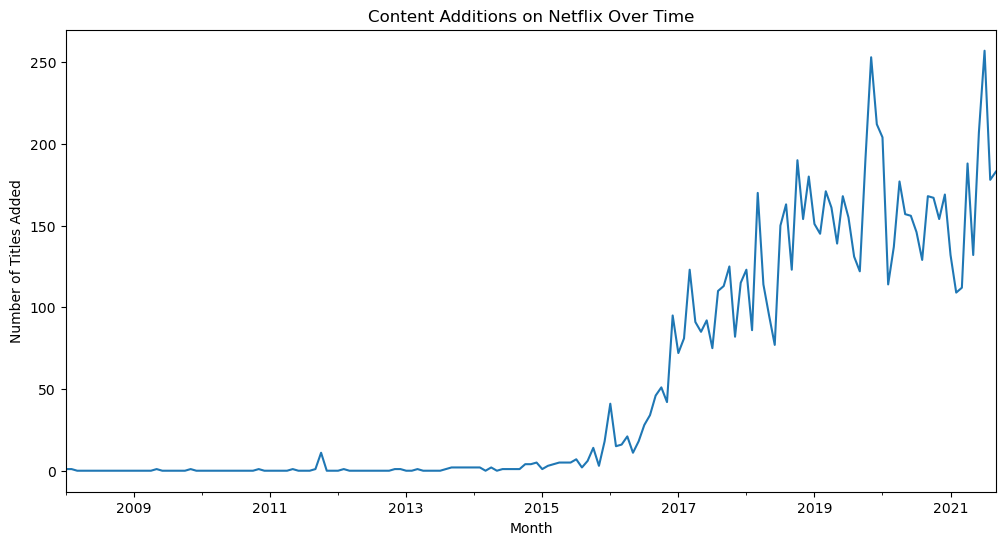

In [112]:
df['date_added'] = pd.to_datetime(df['date_added'], format='%B %d, %Y', errors='coerce')

# Drop rows with invalid date values
df.dropna(subset=['date_added'], inplace=True)


# Group by month and count content additions
content_added_by_month = df.groupby(pd.Grouper(key='date_added', freq='M'))['title'].count()

# Create a time series plot
plt.figure(figsize=(12, 6))
content_added_by_month.plot()
plt.title('Content Additions on Netflix Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Titles Added')
plt.show()

this is no far from the bar plot above but we can still see deeply in the change in the addition of movies through years.  